# Sudan EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats



# Load Data

In [2]:
df = pd.read_csv("../data/sudan.csv")
df["Country"] = "Sudan"
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan


In [3]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,25.18,35.55,16.14,19.41,0.0,31.87,3.46,5.12,96.54,6.08,Sudan,2015-01-01,1
1,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
2,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
3,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
4,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1


## Clean

In [4]:
df.replace(-999, np.nan, inplace=True)

In [5]:
print(df.duplicated(), '\n')
print(f"How many duplicates: {df.duplicated().sum()}")

df = df.drop_duplicates()

0       False
1       False
2       False
3       False
4       False
        ...  
4103    False
4104    False
4105    False
4106    False
4107    False
Length: 4108, dtype: bool 

How many duplicates: 0


In [6]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


# Summary statistics
this is the summmary statistics of all numeric columns

In [7]:
missing = df.isna().sum()#this will give us the percentage of missing values in each column
missing_percent = (missing/len(df)) * 100

high_missing = missing_percent[missing_percent > 5]

if high_missing.empty:
    summary = pd.DataFrame(
        {
            "Missing Count": missing,
            "Missing Percent": missing_percent
        }
    )
    display(summary)

,Missing Count,Missing Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


## Outliers

In [8]:
cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

z_scores = np.abs(stats.zscore(df[cols].dropna(),nan_policy='omit'))
z_df = pd.DataFrame(z_scores, index=df[cols].dropna().index, columns=cols)

outlier_mask = (z_scores > 3).any(axis=1)
print((z_scores > 3).sum())


91


### Outlier Treatment: Retain

**Decision:** I have decided to **retain** the 137 identified outlier rows.

**Reasoning:**
* **Data Authenticity:** In weather data (`T2M`, `PRECTOTCORR`), extremes are often real environmental events (storms or heatwaves) rather than errors.
* **Seasonal Integrity:** Removing these would bias the seasonal analysis by hiding the natural variability of the climate.
* **Model Robustness:** Retaining them ensures the analysis reflects real-world conditions, including high-impact weather peaks.

In [9]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

# 1. Drop rows with more than 30% missing values
df = df.dropna(thresh=int(0.7 * len(df.columns)))
# 2. Forward-fill remaining weather variables
df.fillna(method="ffill", inplace=True)
# 3. Export to CSV (replace)
df.to_csv("../data/sudan_clean.csv", index=False)

C:\Users\HP\AppData\Local\Temp\ipykernel_12772\2368965889.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method="ffill", inplace=True)


## Time series

1. Monthly Average T2M (Line Chart)


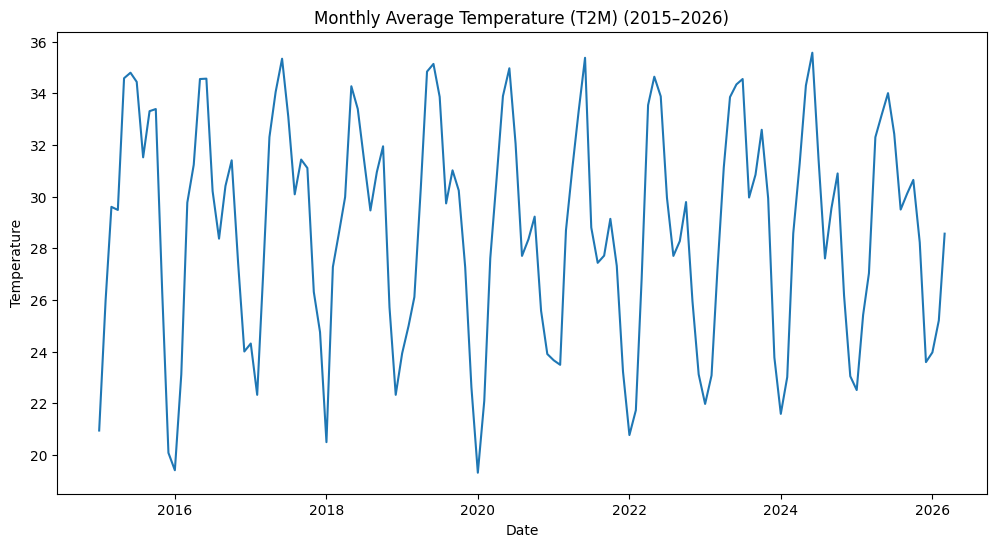

In [10]:
monthly_t2m = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

#Create a proper date for plotting
monthly_t2m["Date"] = pd.to_datetime(monthly_t2m["YEAR"].astype(str) + "-" + monthly_t2m["Month"].astype(str))

#Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])
plt.title("Monthly Average Temperature (T2M) (2015–2026)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()



Annotate Warmest & Coolest Months

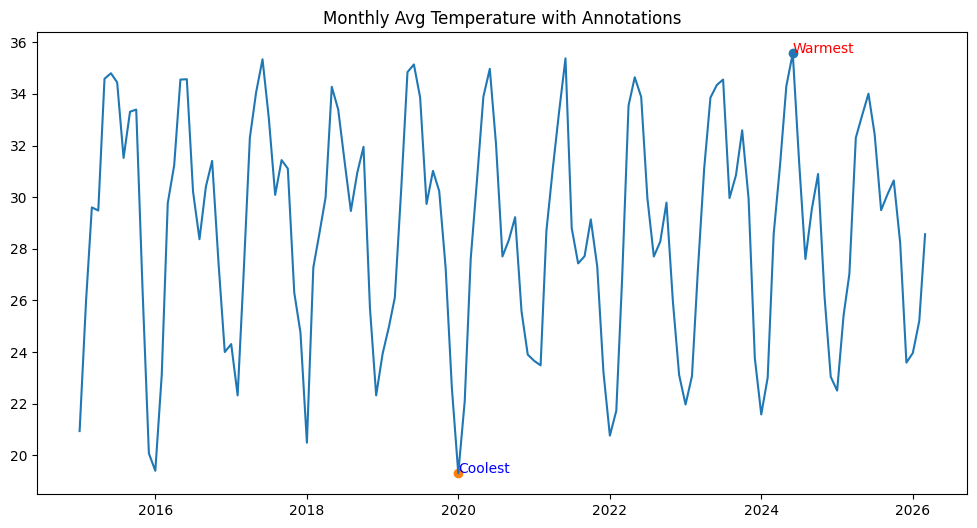

In [11]:
#Annotate Warmest & Coolest Months
max_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmax()]
min_row = monthly_t2m.loc[monthly_t2m["T2M"].idxmin()]

plt.figure(figsize=(12,6))
plt.plot(monthly_t2m["Date"], monthly_t2m["T2M"])

plt.scatter(max_row["Date"], max_row["T2M"])
plt.text(max_row["Date"], max_row["T2M"], "Warmest", color="red")

plt.scatter(min_row["Date"], min_row["T2M"])
plt.text(min_row["Date"], min_row["T2M"], "Coolest", color="blue")

plt.title("Monthly Avg Temperature with Annotations")
plt.show()

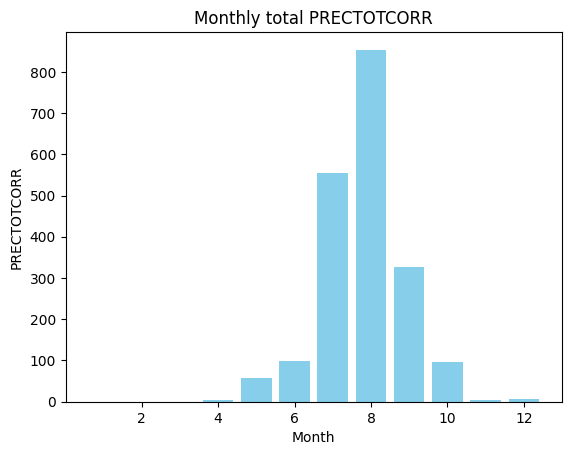

In [12]:

#Monthly Total PRECTOTCORR (Bar Chart)
monthly_precip = df.groupby('Month')['PRECTOTCORR'].sum()
plt.figure()
plt.bar(monthly_precip.index, monthly_precip.values, color='skyblue')
plt.title('Monthly total PRECTOTCORR')
plt.xlabel('Month')
plt.ylabel('PRECTOTCORR')
plt.show()



## Correlation

Correlation Heatmap

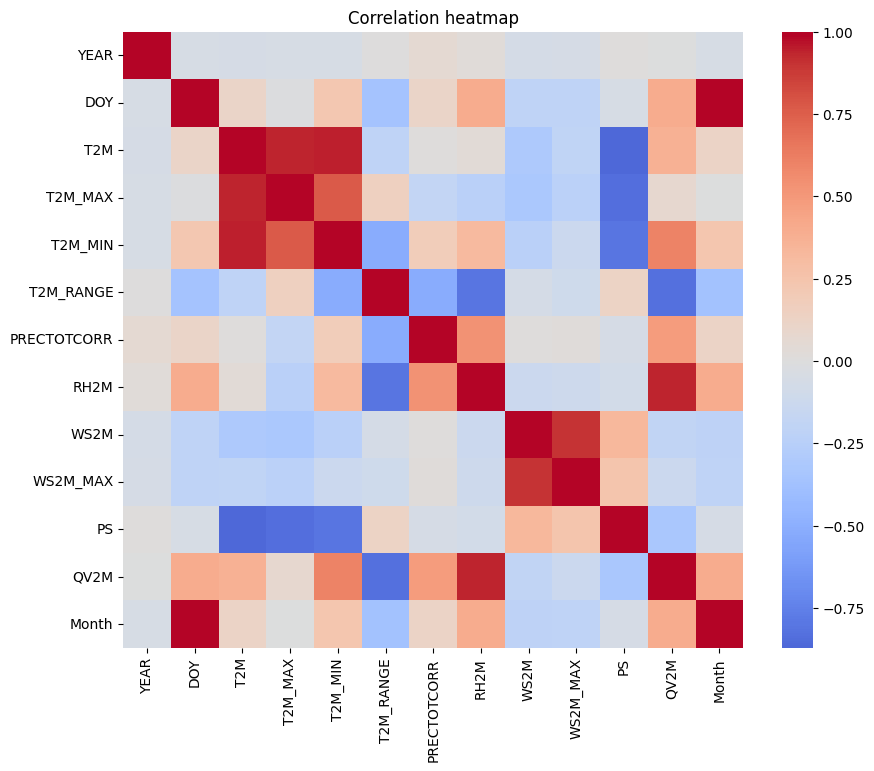

In [13]:
num = df.select_dtypes(include=[np.number])
corr = num.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation heatmap')
plt.show()

Scatter Plot: T2M vs RH2M

DOY      Month    0.996557
Month    DOY      0.996557
T2M_MIN  T2M      0.941859
dtype: float64


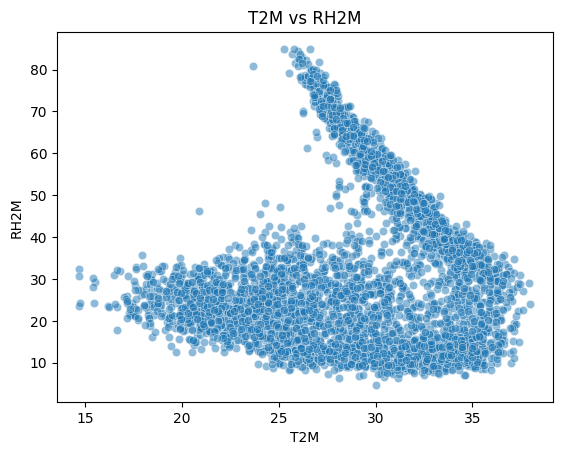

In [14]:
print(corr.unstack().sort_values(ascending=False)[len(corr):len(corr)+3])
plt.figure()
sns.scatterplot(data=df, x='T2M', y='RH2M', alpha=0.5)
plt.title('T2M vs RH2M')
plt.show()

Scatter Plot: T2M_RANGE vs WS2M

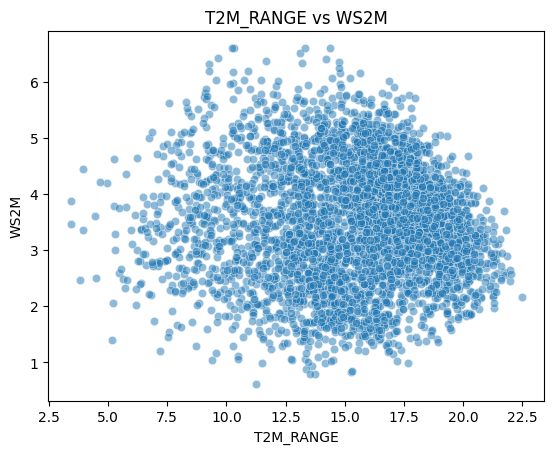

In [15]:

plt.figure()
sns.scatterplot(data=df, x='T2M_RANGE', y='WS2M', alpha=0.5)
plt.title('T2M_RANGE vs WS2M')
plt.show()


## Distribution

Histogram of PRECTOTCORR

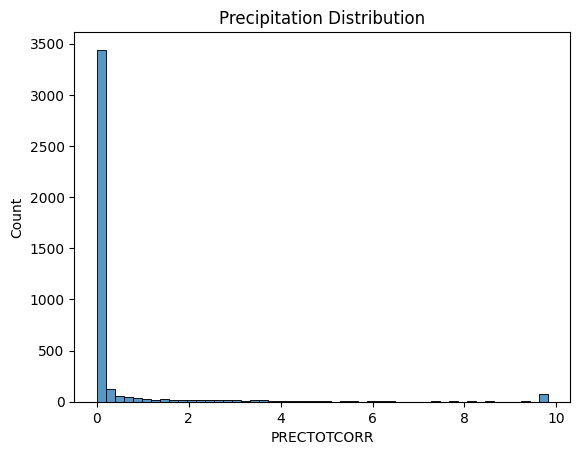

In [16]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Precipitation Distribution")
plt.show()

If skewed → log scale
Right-skewed (positively skewed)

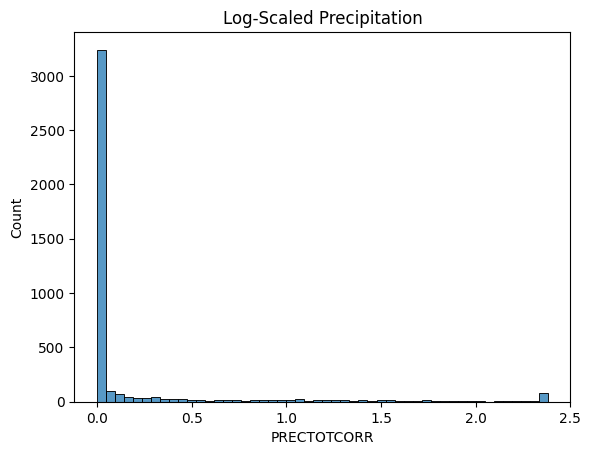

In [17]:
sns.histplot(np.log1p(df["PRECTOTCORR"]), bins=50)
plt.title("Log-Scaled Precipitation")
plt.show()

Bubble Chart

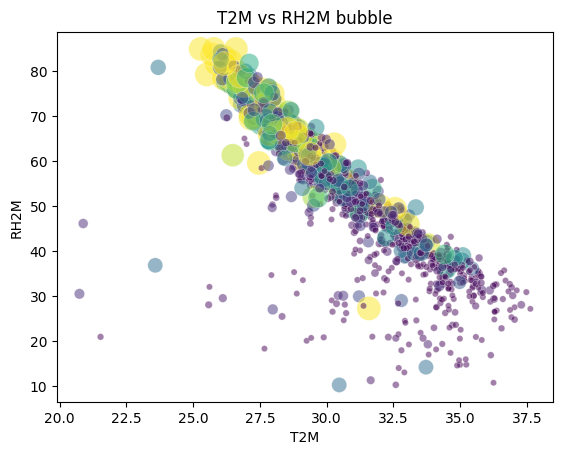

In [18]:
plt.figure()
df2 = df[df['PRECTOTCORR'] > 0]
sns.scatterplot(data=df2, x='T2M', y='RH2M', size='PRECTOTCORR', sizes=(20, 300), alpha=0.5, hue='PRECTOTCORR', palette='viridis', legend=False)
plt.title('T2M vs RH2M bubble')
plt.show()